# 15. Clasificación de textos con Redes Neuronales (Perceptrón Multicapa)

En este notebook vamos a clasificar críticas de películas de FilmAffinity según su **sentimiento** (Negativa, Neutra o Positiva) utilizando un ***Perceptrón Multicapa*** (MLP), en lugar de los clasificadores clásicos que vimos en el notebook `07_clasificacion_textos_ejemplo.ipynb` (Naive Bayes, Regresión Logística, SVM Lineal y Random Forest).

Vamos a seguir representando los textos con **Bag of Words**, igual que en el notebook 07. Un Perceptrón Multicapa es un modelo más flexible y con más capacidad de ajuste que esos clasificadores clásicos, y en la práctica puede llegar a superarlos. Pero conviene tener clara una idea desde el principio, que retomaremos con detalle en las conclusiones: **por muy potente que sea la red neuronal, si su entrada sigue siendo una bolsa de palabras, sigue arrastrando la misma limitación de fondo que los modelos clásicos — no capta relaciones semánticas entre palabras**. Cambiar el algoritmo de aprendizaje no cambia la representación del texto; para eso haría falta cambiar de BoW a embeddings, como los que vimos en los notebooks `13_Ejemplo_embeddings_preentrenados.ipynb` y `14_busqueda_semantica_embeddings.ipynb`.

El sentimiento de cada crítica no viene dado directamente en el dataset, sino que lo derivamos de la nota numérica que el usuario le puso a la película (`review_rate`, en una escala de 1 a 10):

- **Negativa**: nota ≤ 4
- **Neutra**: nota 5 o 6
- **Positiva**: nota ≥ 7

Los pasos que vamos a dar son los siguientes:

1. Cargar los datos
2. Normalizar los textos (con énfasis en que trabajamos con Bag of Words)
3. Particionado de datos (Train y Test)
4. Bolsa de palabras y codificación del target
5. Definición de la Red Neuronal
6. Entrenamiento de la Red Neuronal
7. Evaluación del modelo

---

## 1. Carga de datos

El fichero `corpus/reviews_filmaffinity.csv` usa `||` como separador y contiene, entre otras columnas, el nombre de la película, el género, la nota media de la película, la nota que puso el usuario (`review_rate`), el título de la crítica (`review_title`) y el cuerpo de la crítica (`review_text`).

Como texto de entrada usamos la **concatenación del título y el cuerpo de la crítica**: el título suele resumir la opinión general y aporta señal adicional para la clasificación.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

df = pd.read_csv('corpus/reviews_filmaffinity.csv', sep='\|\|', engine='python')

# Descartamos las filas sin nota, ya que no podemos derivar el sentimiento
df = df.dropna(subset=['review_rate'])

# El texto de entrada es la concatenacion del titulo y el cuerpo de la critica
df['texto'] = df['review_title'].fillna('') + '. ' + df['review_text'].fillna('')

# Derivamos el sentimiento a partir de la nota numerica (review_rate)
def nota_a_sentimiento(nota):
    if nota <= 4:
        return 'Negativa'
    elif nota <= 6:
        return 'Neutra'
    else:
        return 'Positiva'

df['sentimiento'] = df['review_rate'].apply(nota_a_sentimiento)

print(f'Total de criticas: {len(df)}')
print()
print('Distribucion por sentimiento:')
print(df['sentimiento'].value_counts())
print()
print((df['sentimiento'].value_counts(normalize=True) * 100).round(1))
print()
df[['review_rate', 'sentimiento', 'texto']].sample(3)

Total de criticas: 8601

Distribucion por sentimiento:
sentimiento
Positiva    3920
Negativa    2447
Neutra      2234
Name: count, dtype: int64

sentimiento
Positiva    45.6
Negativa    28.5
Neutra      26.0
Name: proportion, dtype: float64



,review_rate,sentimiento,texto
122,3.0,Negativa,SIN 8 APELLIDOS VASCOS. Tras 308 críticas y re...
5889,1.0,Negativa,¿de verdad hemos retrocedido tanto?. ¿De verda...
6066,5.0,Neutra,Muy simple. No voy a decir que sea una películ...


Como se puede ver, el dataset está **desbalanceado**: la clase Positiva (45.6 %) tiene casi el doble de críticas que la clase Neutra (26.0 %). Esta proporción se mantendrá tanto en el conjunto de entrenamiento como en el de test una vez particionemos los datos (sección 3), y tendremos que tenerla en cuenta también al entrenar la red neuronal (sección 6), igual que hicimos con `class_weight='balanced'` en los modelos clásicos del notebook 07.

---

## 2. Normalización de los textos

Vamos a representar los textos con **Bag of Words**: cada crítica se convertirá en un vector de frecuencias sobre un vocabulario común. A diferencia de los embeddings preentrenados que vimos en los notebooks `13_Ejemplo_embeddings_preentrenados.ipynb` y `14_busqueda_semantica_embeddings.ipynb` —donde la normalización debía ser ligera para no alejar el texto del lenguaje natural con el que se entrenó el modelo—, aquí el objetivo es justo el contrario: **reducir el vocabulario y quedarnos solo con las palabras más informativas**, exactamente igual que en el notebook `07_clasificacion_textos_ejemplo.ipynb`.

Por eso aplicamos con spaCy una normalización agresiva:

- Convertir a minúsculas
- Eliminar puntuación y tokens no alfabéticos
- Eliminar *stopwords* del español
- Eliminar tokens de menos de 3 caracteres
- Aplicar lematización
- Eliminar acentos, diéresis y otros diacríticos

> **Nota**: las críticas de FilmAffinity son bastante más largas que los tuits o las noticias de los notebooks anteriores (de media, unos 1.250 caracteres), así que la normalización de las más de 8.500 críticas tardará varios minutos.

#### CUIDADO — IMPORTANTE

* Dado que el proceso de normalización es lento, guardamos el resultado (`X` normalizado e `y`) en un fichero binario (`.pkl`) la primera vez que se ejecuta.

* En las siguientes ejecuciones del notebook, si ese fichero ya existe, lo cargamos directamente y **no volvemos a normalizar los textos**, ahorrando varios minutos de ejecución. Si quieres forzar una renormalización (por ejemplo, tras cambiar la función `normalizar`), basta con borrar el fichero `models/X_y_normalizado_reviews.pkl`.

In [2]:
import os
import pickle
import unicodedata
import spacy
from tqdm import tqdm

PICKLE_PATH = 'models/15_X_y_normalizado_reviews_peliculas.pkl'

nlp = spacy.load('es_core_news_sm')

def quitar_acentos(texto):
    """Elimina acentos, diéresis y otros diacríticos de una cadena."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def normalizar(textos):
    resultado = []
    for texto in tqdm(textos):
        doc = nlp(texto.lower())
        tokens = [
            quitar_acentos(token.lemma_)
            for token in doc
            if not token.is_stop
            and not token.is_punct
            and token.is_alpha
            and len(token.text) > 2
        ]
        resultado.append(' '.join(tokens))
    return resultado

if os.path.exists(PICKLE_PATH):
    # Ya existe el fichero con los textos normalizados: lo cargamos y nos ahorramos la normalizacion
    print(f'Cargando textos normalizados desde {PICKLE_PATH} ...')
    with open(PICKLE_PATH, 'rb') as f:
        X, y = pickle.load(f)
else:
    # Primera ejecucion: normalizamos y guardamos el resultado para las siguientes ejecuciones
    X = df['texto'].tolist()
    y = df['sentimiento'].tolist()
    X = normalizar(X)

    os.makedirs('models', exist_ok=True)
    with open(PICKLE_PATH, 'wb') as f:
        pickle.dump((X, y), f)
    print(f'\nTextos normalizados guardados en {PICKLE_PATH}')

print('Original:   ', df['texto'].iloc[0][:200], '...')
print('\nNormalizado:', X[0][:200], '...')

Cargando textos normalizados desde models/15_X_y_normalizado_reviews_peliculas.pkl ...
Original:    OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO. La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...

Normalizado: apellido vasco nombre virtud pelicula poder jugar topico extremo identidad patrio andaluz vasco escandalizar poner grito cielo indicar madurez nacion pese pese corrijo poder jugar mofa befa topico vas ...


---

## 3. Particionado de datos (Train y Test)

A diferencia de un corpus de tuits, donde las temáticas cambian con el tiempo y conviene partir los datos cronológicamente, las críticas de cine no tienen ese componente temporal, así que hacemos una partición aleatoria estratificada: 80 % de entrenamiento y 20 % de test, manteniendo la proporción de cada clase de sentimiento en ambos conjuntos.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Criticas de entrenamiento: {len(X_train)}')
print(f'Criticas de test:          {len(X_test)}')

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()
df_dist = pd.DataFrame({
    'Train (n)':  train_counts,
    'Train (%)':  (train_counts / len(y_train) * 100).round(1),
    'Test (n)':   test_counts,
    'Test (%)':   (test_counts / len(y_test) * 100).round(1),
})
df_dist

Criticas de entrenamiento: 6880
Criticas de test:          1721


,Train (n),Train (%),Test (n),Test (%)
Negativa,1957,28.4,490,28.5
Neutra,1787,26.0,447,26.0
Positiva,3136,45.6,784,45.6


---

## 4. Bolsa de palabras y codificación del target

Cuando trabajamos con redes neuronales para clasificación de textos necesitamos:

1. **Input**: un vector por documento en el que cada posición represente el peso de una palabra en ese documento (por frecuencia, presencia/ausencia o TF-IDF).
2. **Output**: un valor numérico, ya que la red no entiende etiquetas de texto como `'Positiva'`. Al ser una clasificación con 3 categorías, codificaremos el sentimiento como 0, 1 y 2.

Para construir la bolsa de palabras usamos la clase `Tokenizer` de TensorFlow-Keras, quedándonos con las `num_words` palabras más frecuentes del corpus de entrenamiento. Esa cifra será, además, el **número de neuronas de entrada** de la red.

Para codificar el sentimiento usamos `LabelEncoder` de scikit-learn, igual que en el notebook 07.

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder

# Bolsa de palabras: nos quedamos con las 3000 palabras mas frecuentes
num_words = 3000
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(X_train)

X_matrix_train = tokenizer.texts_to_matrix(X_train, mode='count')
X_matrix_test  = tokenizer.texts_to_matrix(X_test, mode='count')

print(f'Vocabulario total del corpus de entrenamiento: {len(tokenizer.word_index)} terminos')
print(f'Vocabulario utilizado (num_words):             {num_words} terminos')
print(f'Dimension de la matriz de entrenamiento: {X_matrix_train.shape}')
print(f'Dimension de la matriz de test:          {X_matrix_test.shape}')

# Codificacion del target: Negativa=0, Neutra=1, Positiva=2 (orden alfabetico)
encoder = LabelEncoder()
encoder.fit(y_train)
y_train_enc = encoder.transform(y_train)
y_test_enc  = encoder.transform(y_test)

print(f'\nClases codificadas: {list(encoder.classes_)}')

Vocabulario total del corpus de entrenamiento: 34190 terminos
Vocabulario utilizado (num_words):             3000 terminos
Dimension de la matriz de entrenamiento: (6880, 3000)
Dimension de la matriz de test:          (1721, 3000)

Clases codificadas: [np.str_('Negativa'), np.str_('Neutra'), np.str_('Positiva')]


---

## 5. Definición de la Red Neuronal

Para clasificar las críticas en una de las 3 categorías de sentimiento, definimos la siguiente arquitectura:

- **Capa de entrada**: `num_words` neuronas (una por palabra del vocabulario)
- **Capa 2**: 64 neuronas con activación `relu`
- **Capa 3**: 32 neuronas con activación `relu`
- **Capa de salida**: 3 neuronas (una por clase de sentimiento) con activación `softmax`, que normaliza la salida para que las 3 probabilidades sumen 1

En las capas 2 y 3 añadimos un `Dropout` del 20 % para reducir el sobreajuste.

Compilamos el modelo con:

- **Función de pérdida**: `sparse_categorical_crossentropy` (adecuada para clasificación multiclase cuando el target son enteros, como los que genera `LabelEncoder`, en lugar de vectores one-hot)
- **Optimizador**: `adam`
- **Métrica**: `accuracy`

In [5]:
# Se fuerza a usar la CPU y no la GPU en caso de tener GPU en el ordenador
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

tf.keras.utils.set_random_seed(42)   # fija a la vez las semillas de Python, NumPy y TensorFlow
tf.config.experimental.enable_op_determinism()   # evita variaciones por el orden de operaciones en coma flotante entre ejecuciones

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=num_words))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(3, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │         192,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 194,243 (758.76 KB)

 Trainable params: 194,243 (758.76 KB)

 Non-trainable params: 0 (0.00 B)

Fíjate en que la tabla de `model.summary()` **no muestra una fila explícita con las 3.000 neuronas de entrada**. Esto no es un error: Keras nunca representa la capa de entrada como una fila propia en un modelo `Sequential`, porque no es una capa que realice ningún cómputo, solo especifica la forma de los datos que entran a la red.

Podemos comprobar que esas 3.000 neuronas de entrada sí están ahí, mirando el número de parámetros de la primera capa oculta (`dense`): **192.064**. Esa cifra es exactamente:

$$ (3.000 \text{ entradas} \times 64 \text{ neuronas}) + 64 \text{ sesgos (bias)} = 192.000 + 64 = 192.064 $$

Es decir, cada una de las 64 neuronas de la primera capa oculta tiene una conexión con cada una de las 3.000 neuronas de entrada (más su propio sesgo), tal y como esperábamos.

---

## 6. Entrenamiento de la Red Neuronal

Antes de entrenar, tenemos que resolver dos cuestiones que ya habíamos anunciado:

* **Desbalanceo de clases**: igual que hicimos con `class_weight='balanced'` en los modelos clásicos del notebook 07, calculamos un peso por clase inversamente proporcional a su frecuencia, y se lo pasamos a `fit()` a través del parámetro `class_weight`. Así, un error en la clase minoritaria (Neutra) penaliza más que un error en la clase mayoritaria (Positiva).

* **Sobreajuste**: con un vector de entrada de 3.000 posiciones y relativamente pocos documentos de entrenamiento (6.880), la red tiene muchísimos parámetros que ajustar en relación con los datos disponibles. Esto es habitual al entrenar redes neuronales sobre bolsas de palabras: la red puede llegar a memorizar el vocabulario exacto de las críticas de entrenamiento en muy pocos *epochs*, por lo que **el número de epochs necesario en NLP con BoW suele ser mucho menor que en otros dominios** (imagen, por ejemplo). Vamos a comprobarlo empíricamente entrenando 10 epochs y observando cómo evoluciona el accuracy de test frente al de entrenamiento.

* Para no depender de "adivinar" el número óptimo de epochs a mano, guardamos en cada epoch el modelo si mejora respecto al mejor visto hasta el momento. Aquí surge una pregunta importante: ¿mejora respecto a qué métrica?

    - Keras trae de serie un *callback* `ModelCheckpoint` que puede monitorizar cualquier métrica calculada durante el entrenamiento, por ejemplo `val_accuracy`. Pero como el dataset está desbalanceado, el accuracy favorece a la clase mayoritaria (Positiva) y puede ocultar que el modelo generaliza mal en la clase minoritaria (Neutra). Es más coherente con lo que nos importa realmente monitorizar el **F1 ponderado**, la misma métrica que usamos para evaluar en la sección 7.

    - El problema es que el `F1Score` que trae Keras espera las etiquetas en formato *one-hot*, y nosotros estamos usando etiquetas enteras (`sparse_categorical_crossentropy`), así que no podemos usarlo directamente como métrica de Keras sin cambiar la codificación del target en todo el notebook.

    - La solución más sencilla es escribir un *callback* propio que, al final de cada epoch, calcule el F1 ponderado de scikit-learn tanto en train como en test, y guarde el modelo en un único fichero dentro de `models/` si el F1 de test mejora respecto al mejor visto hasta ese momento. Además, registramos ambos valores para poder representarlos más adelante junto a la pérdida y el accuracy.

Entrenamos la red llamando al método `fit()`, indicando:

- `batch_size=64`: número de críticas que se procesan antes de actualizar los pesos de la red.
- `epochs=10`: número de veces que la red recorrerá el conjunto de entrenamiento completo.
- `validation_data=(X_matrix_test, y_test_enc)`: en cada epoch se evalúa también el modelo sobre el conjunto de test, para poder comparar cómo evolucionan las métricas de entrenamiento y de test.
- `class_weight`: los pesos por clase calculados para compensar el desbalanceo.
- `callbacks=[checkpoint_f1]`: nuestro *callback* que guarda el mejor modelo según el F1 ponderado de test.

In [7]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score

# Pesos por clase para compensar el desbalanceo (igual que class_weight='balanced' en el notebook 07)
pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = {clase: peso for clase, peso in zip(np.unique(y_train_enc), pesos)}

print('Pesos por clase:')
for clase_enc, peso in class_weight_dict.items():
    print(f'  {encoder.inverse_transform([clase_enc])[0]:10s} (clase {clase_enc}): {peso:.3f}')


class F1Checkpoint(Callback):
    """Calcula el F1 ponderado en train y test al final de cada epoch, los registra para
    poder representarlos despues, y guarda en un unico fichero el modelo con mejor F1 de test."""

    def __init__(self, filepath, X_train, y_train_enc, X_val, y_val_enc):
        super().__init__()
        self.filepath = filepath
        self.X_train = X_train
        self.y_train_enc = y_train_enc
        self.X_val = X_val
        self.y_val_enc = y_val_enc
        self.best_f1 = -1.0
        self.f1_train_history = []
        self.f1_val_history = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred_train_enc = np.argmax(self.model.predict(self.X_train, verbose=0), axis=-1)
        y_pred_val_enc   = np.argmax(self.model.predict(self.X_val, verbose=0), axis=-1)

        f1_train = f1_score(self.y_train_enc, y_pred_train_enc, average='weighted')
        f1_val   = f1_score(self.y_val_enc, y_pred_val_enc, average='weighted')

        self.f1_train_history.append(f1_train)
        self.f1_val_history.append(f1_val)

        if f1_val > self.best_f1:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> mejora, guardando modelo en {self.filepath}')
            self.best_f1 = f1_val
            self.model.save(self.filepath)
        else:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> no mejora el mejor val_f1 ({self.best_f1:.4f})')


# Guardamos en un unico fichero el modelo con mejor F1 ponderado de test visto durante el entrenamiento
MODEL_PATH = 'models/15_mejor_modelo_mlp_reviews.keras'
os.makedirs('models', exist_ok=True)

checkpoint_f1 = F1Checkpoint(
    filepath=MODEL_PATH,
    X_train=X_matrix_train, y_train_enc=y_train_enc,
    X_val=X_matrix_test, y_val_enc=y_test_enc
)

Pesos por clase:
  Negativa   (clase 0): 1.172
  Neutra     (clase 1): 1.283
  Positiva   (clase 2): 0.731


In [8]:
history = model.fit(
    X_matrix_train, y_train_enc,
    batch_size=64,
    epochs=10,
    verbose=2,
    validation_data=(X_matrix_test, y_test_enc),
    class_weight=class_weight_dict,
    callbacks=[checkpoint_f1]
)

# Incorporamos el F1 de train/test registrado por el callback al historico,
# para poder representarlo con la misma funcion plot_metric que loss y accuracy
history.history['f1'] = checkpoint_f1.f1_train_history
history.history['val_f1'] = checkpoint_f1.f1_val_history

Epoch 1/10

Epoch 1: f1: 0.7580 - val_f1: 0.6532 -> mejora, guardando modelo en models/15_mejor_modelo_mlp_reviews.keras
108/108 - 3s - 25ms/step - accuracy: 0.5269 - loss: 0.9870 - val_accuracy: 0.6485 - val_loss: 0.8104
Epoch 2/10

Epoch 2: f1: 0.8503 - val_f1: 0.6763 -> mejora, guardando modelo en models/15_mejor_modelo_mlp_reviews.keras
108/108 - 1s - 10ms/step - accuracy: 0.7231 - loss: 0.6912 - val_accuracy: 0.6740 - val_loss: 0.7646
Epoch 3/10

Epoch 3: f1: 0.9063 - val_f1: 0.6600 -> no mejora el mejor val_f1 (0.6763)
108/108 - 1s - 12ms/step - accuracy: 0.8038 - loss: 0.5065 - val_accuracy: 0.6601 - val_loss: 0.8242
Epoch 4/10

Epoch 4: f1: 0.9504 - val_f1: 0.6586 -> no mejora el mejor val_f1 (0.6763)
108/108 - 2s - 17ms/step - accuracy: 0.8746 - loss: 0.3502 - val_accuracy: 0.6618 - val_loss: 0.9069
Epoch 5/10

Epoch 5: f1: 0.9777 - val_f1: 0.6526 -> no mejora el mejor val_f1 (0.6763)
108/108 - 4s - 37ms/step - accuracy: 0.9193 - loss: 0.2393 - val_accuracy: 0.6543 - val_loss:

Representamos cómo evolucionan la función de pérdida, el accuracy y el F1 ponderado en cada epoch, tanto en entrenamiento como en test. Si la curva de test se separa mucho de la de entrenamiento (la de test empeora mientras la de entrenamiento sigue mejorando), es una señal de sobreajuste.

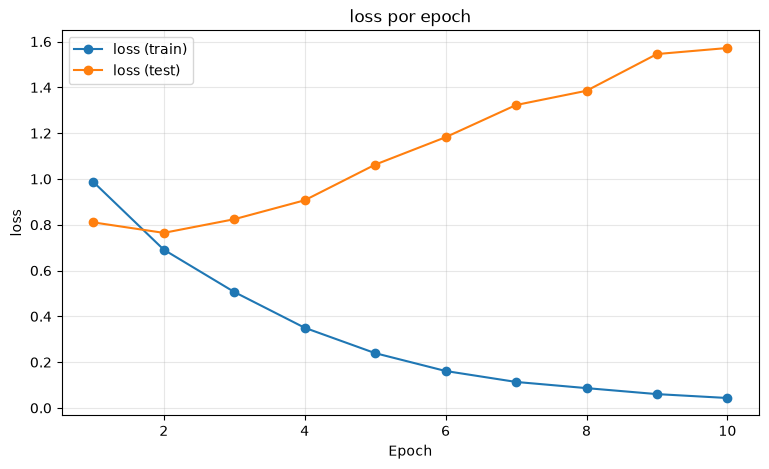

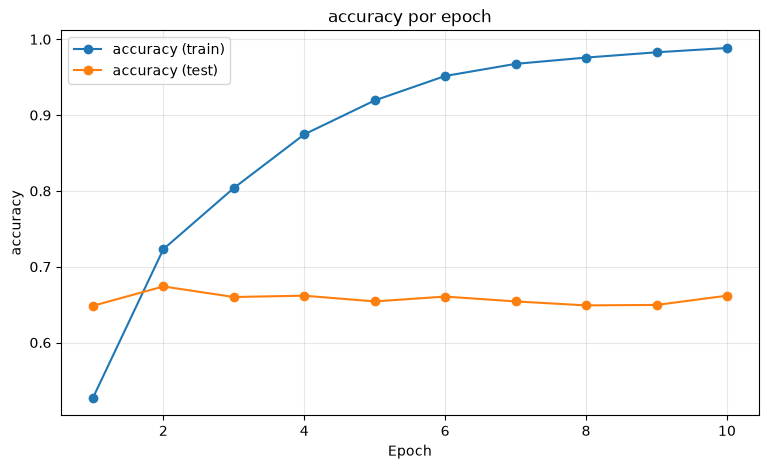

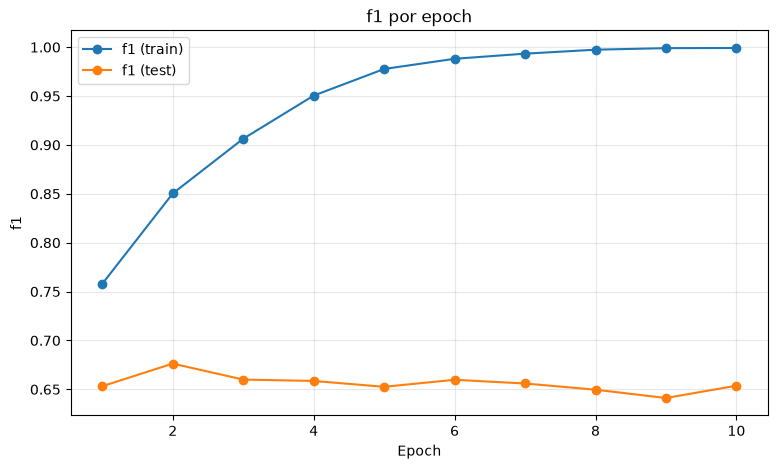

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metric(history, name):
    metric_train = history.history[name]
    metric_test  = history.history[f'val_{name}']
    epochs_range = range(1, len(metric_train) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs_range, metric_train, marker='o', label=f'{name} (train)')
    plt.plot(epochs_range, metric_test, marker='o', label=f'{name} (test)')
    plt.title(f'{name} por epoch')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(history, 'loss')
plot_metric(history, 'accuracy')
plot_metric(history, 'f1')

---

## 7. Evaluación del modelo

El objeto `model` que tenemos en memoria corresponde a los pesos del **último** epoch entrenado, que muy probablemente esté sobreajustado. Por eso, para evaluar, cargamos desde disco el modelo que nuestro *callback* `F1Checkpoint` guardó como mejor resultado de F1 ponderado en test durante el entrenamiento, y evaluamos con ese modelo en lugar de con `model`.

Calculamos las métricas de evaluación habituales para clasificación —Accuracy, Precision, Recall y F1 (ponderado, ya que las clases de sentimiento no están perfectamente balanceadas)— y mostramos las matrices de confusión de entrenamiento y de test.

In [10]:
from tensorflow.keras.models import load_model

# Cargamos el mejor modelo guardado durante el entrenamiento (mejor val_accuracy)
modelo_mlp = load_model(MODEL_PATH)
print(f'Modelo cargado desde: {MODEL_PATH}')

Modelo cargado desde: models/15_mejor_modelo_mlp_reviews.keras


In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)

y_pred_test_enc  = np.argmax(modelo_mlp.predict(X_matrix_test), axis=-1)
y_pred_train_enc = np.argmax(modelo_mlp.predict(X_matrix_train), axis=-1)

y_pred_test  = encoder.inverse_transform(y_pred_test_enc)
y_pred_train = encoder.inverse_transform(y_pred_train_enc)

print('--- Evaluacion en TEST ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_test, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_test))

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
--- Evaluacion en TEST ---
Accuracy:  0.6740
Precision: 0.6808
Recall:    0.6740
F1:        0.6763

              precision    recall  f1-score   support

    Negativa       0.65      0.72      0.68       490
      Neutra       0.49      0.50      0.50       447
    Positiva       0.81      0.74      0.78       784

    accuracy                           0.67      1721
   macro avg       0.65      0.65      0.65      1721
weighted avg       0.68      0.67      0.68      1721



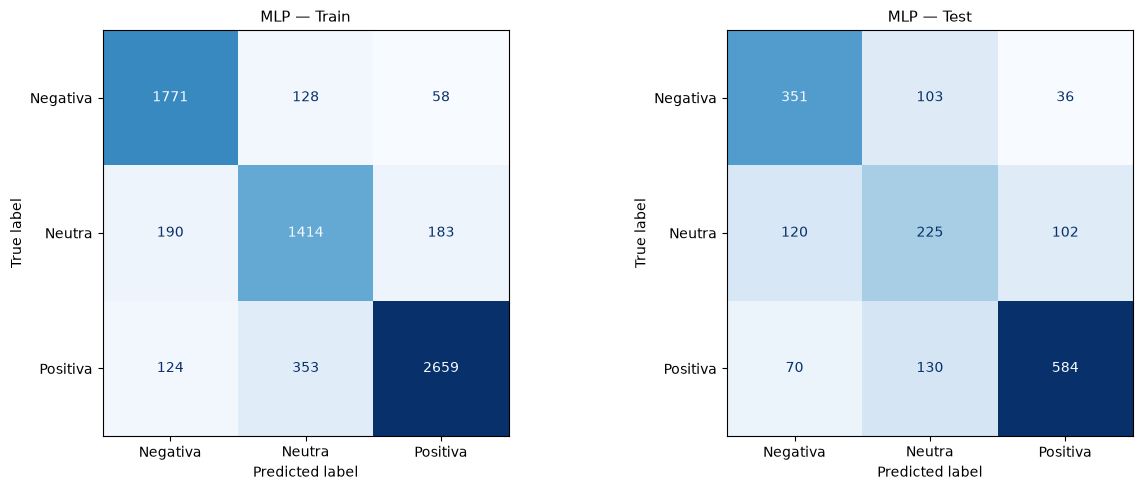

In [12]:
clases = list(encoder.classes_)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('MLP — Train', fontsize=11)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[1])
axes[1].set_title('MLP — Test', fontsize=11)

plt.tight_layout()
plt.show()

## Conclusiones

* El `F1Checkpoint` se quedó con el modelo del **epoch 3** de los 10 entrenados (val_f1 = 0.6712). A partir de ahí, el F1 de entrenamiento sigue subiendo hasta prácticamente 1.0 (0.9985 en el último epoch), mientras que el F1 de test nunca vuelve a superar el valor del epoch 3 y llega a bajar hasta 0.64 antes de recuperarse ligeramente al final. Es la confirmación empírica de lo que anunciábamos en la sección 6: con una entrada de 3.000 posiciones (BoW) y unos pocos miles de documentos, la red memoriza el vocabulario de entrenamiento en muy pocas pasadas, y seguir entrenando después de ese punto solo empeora la generalización.

* El modelo cargado desde disco (el del epoch 3) obtiene un accuracy en test del 67.46 % y un F1 ponderado de 0.6712, con un F1 de la clase Neutra de 0.47. Comparado con el punto de partida —entrenar sin `class_weight` y evaluar con los pesos del último epoch: accuracy 64.0 %, F1 0.63, F1 de Neutra 0.39—, la combinación de compensar el desbalanceo con `class_weight` y quedarnos con el mejor epoch según F1 ponderado mejora el resultado global, y sobre todo mejora notablemente la clase más débil: el F1 de Neutra sube de 0.39 a 0.47 (recall de 0.34 a 0.45).

* Compara estos resultados con los que obtuvimos en el notebook `07_clasificacion_textos_ejemplo.ipynb` con Naive Bayes, Regresión Logística, SVM Lineal y Random Forest: el Perceptrón Multicapa es un modelo más flexible y con más capacidad de ajuste, pero eso no lo libra de las mismas limitaciones estructurales que afectan a esos modelos clásicos.

* La razón es que, **por muy sofisticada que sea la red neuronal, su entrada sigue siendo una bolsa de palabras**. Todo lo que la red puede aprender está limitado por la información que contiene ese vector de frecuencias: cuántas veces aparece cada palabra del vocabulario, sin ningún tipo de relación semántica entre ellas. Para el modelo, "buena" y "excelente" son dos columnas de la matriz tan distintas entre sí como "buena" y "aburrida"; no hay ninguna noción de que las dos primeras expresan una valoración parecida. Esto penaliza especialmente a la clase Neutra, cuyo vocabulario es intrínsecamente más matizado y solapado con el de las otras dos clases.

* Esto contrasta directamente con lo que vimos en los notebooks `13_Ejemplo_embeddings_preentrenados.ipynb` y `14_busqueda_semantica_embeddings.ipynb`: los embeddings preentrenados sí capturan relaciones semánticas entre palabras, porque su representación no depende de "qué palabras aparecen" sino de "qué significan". Cambiar el algoritmo de clasificación (de Naive Bayes a una red neuronal), ajustar el desbalanceo con `class_weight` o elegir con cuidado la métrica de selección del mejor epoch mejoran la capacidad de ajuste del modelo, pero **no resuelven la limitación de fondo**, que está en la representación de entrada (BoW), no en el clasificador ni en el proceso de entrenamiento.

* En la práctica, esto explica por qué las arquitecturas modernas de NLP (redes recurrentes, transformers) no alimentan sus modelos con bolsas de palabras, sino con embeddings: el salto de calidad más importante no vino de mejorar el clasificador, sino de mejorar la representación del texto.

---

# Bonus Track I — Perceptrón Multicapa (MLP)

* El Perceptrón Multicapa (*Multilayer Perceptron*, MLP) es una Red Neuronal Artificial cuyo objetivo es resolver problemas de clasificación o regresión que no son linealmente separables.

* El MLP está formado por una serie de capas compuestas por neuronas, estando cada neurona de una capa conectada con todas las neuronas de la capa siguiente. Las capas de una red neuronal se dividen en 3 tipos:

    - **Capa de entrada**: formada por tantas neuronas como variables tengan los elementos de entrada (en nuestro caso, `num_words`, una por palabra del vocabulario). Las neuronas de la capa de entrada no realizan ningún procesamiento, solo introducen los datos en la red.
    - **Capas ocultas**: compuestas por neuronas cuyas entradas provienen de las salidas de la capa anterior, y cuyas salidas alimentan a la capa siguiente.
    - **Capa de salida**: compuesta por una o más neuronas, cuyos valores corresponden a la salida final de la red (en nuestro caso, 3 neuronas con `softmax`, una probabilidad por clase de sentimiento).


<img src="imgs/013_mlp.png" style="width: 700px;"/>

## Entrenar una Red Neuronal

De manera general, para crear y entrenar un Perceptrón Multicapa hay que seguir los siguientes pasos:

1. **Recopilar el conjunto de datos** (cuantos más datos, generalmente mejor).
2. **Diseñar una función de pérdida** apropiada para el problema:
    - MSE (*Mean Squared Error*) para problemas de regresión.
    - *Cross Entropy* para problemas de clasificación: `binary_crossentropy` para clasificación binaria, `categorical_crossentropy` o `sparse_categorical_crossentropy` para clasificación multiclase (como en este notebook).
3. **Definir la arquitectura de la Red Neuronal** y sus hiperparámetros:
   - número de capas y neuronas por capa
   - funciones de activación
   - *learning rate*
   - *epochs*
   - *batch size*
   - etc.
4. **Aplicar un algoritmo de optimización** que ajuste los pesos de la red minimizando la función de pérdida
   - *Stochastic Gradient Descent* (SGD)
   - RMSProp
   - Adam (esta suele ser la más usada)
   - AdaGrad
   - AdaDelta
   - AdaMax...

## Dropout

* El `Dropout` es una técnica de regularización cuyo objetivo es reducir el sobreajuste (*overfitting*).

* Consiste en **perturbar la red** en cada pasada de entrenamiento (*feed-forward* y *backpropagation*), **eliminando al azar** algunas de las neuronas de la capa a la que se aplica, con la probabilidad indicada (en nuestro modelo, 0.2 → 20 % de las neuronas de esa capa se desactivan en cada pasada).

* Al introducir este "ruido" durante el entrenamiento, se evita que la red dependa en exceso de un pequeño grupo de neuronas concretas, obligándola a aprender una representación más robusta y generalizable.


<img src="imgs/014_drop_out.png" style="width: 700px;"/>

---

## Hiperparámetros de la Red

### Epochs

* Los *epochs* (épocas) indican el **número de veces que la Red Neuronal recorrerá el conjunto de entrenamiento completo**.

* Por ejemplo, si tenemos 8.000 críticas y entrenamos con 10 epochs, la red leerá y aprenderá de esas 8.000 críticas 10 veces, es decir, procesará 80.000 críticas en total a lo largo del entrenamiento.


<img src="imgs/015_epochs.png" style="width: 700px;"/>


### Batch Size

* El *batch size* indica el **número de observaciones que la Red Neuronal procesa antes de actualizar sus pesos**.

* Con un `batch_size=64`, la red calcula la salida para 64 críticas, calcula el error medio de esas 64 predicciones, y solo entonces actualiza los pesos de la red.

    - **Batch size pequeño**: la red actualiza los pesos con más frecuencia y puede aprender mejor, pero el entrenamiento tarda más tiempo.
    - **Batch size grande**: el entrenamiento es más rápido, pero cada actualización de pesos se basa en un promedio de más ejemplos, lo que puede hacer que la red generalice algo peor.

<img src="imgs/016_batch_size.png" style="width: 700px;"/>

<hr>

# Bonus Track II — TensorFlow y Keras

* **TensorFlow** es una librería de *Deep Learning* en Python desarrollada por Google.

* **Keras** es una librería en Python desarrollada por François Chollet (ingeniero de Google) que, en esencia, es una interfaz de alto nivel (*wrapper*) sobre TensorFlow, Theano y CNTK.

* TensorFlow, Theano y CNTK son librerías muy potentes, pero con el "problema" de ser difíciles de utilizar directamente. Por eso Keras se desarrolló con el objetivo de ofrecer una librería sencilla para trabajar en *Deep Learning*.

* A partir de la versión 2 de TensorFlow, Keras se integró directamente como su API de alto nivel (`tensorflow.keras`), que es precisamente la que hemos utilizado en este notebook (`from tensorflow.keras.models import Sequential`, etc.), con el objetivo de simplificar y democratizar su uso.

* Los principios de diseño de Keras son:

    - **Modularidad**: una red neuronal se entiende como una secuencia (o grafo) de capas.
    - **Minimalismo**: la librería proporciona lo justo y necesario para crear y entrenar redes, maximizando la legibilidad del código.
    - **Extensibilidad**: los nuevos componentes deben ser fáciles de añadir.
    - **Python nativo**: Keras está pensado para integrarse de forma natural en código Python.

## Cómo construir modelos en TensorFlow - Keras

De forma genérica, los pasos para construir una red neuronal con Keras son los que hemos seguido en este notebook:

1. **Definir el modelo**: crear un modelo `Sequential` y añadir las capas con su configuración (`model.add(Dense(...))`, `model.add(Dropout(...))`...).
2. **Compilar el modelo**: especificar la función de pérdida, el optimizador y las métricas con `model.compile()`.
3. **Ajustar (entrenar) el modelo**: entrenar la red con los datos de entrenamiento llamando a `model.fit()`.
4. **Realizar predicciones**: usar el modelo entrenado para predecir sobre datos nuevos con `model.predict()`, o evaluarlo sobre un conjunto de datos con `model.evaluate()`.